# Marketing Mix Modeling: Otimização de Investimento em Mídia
   *Qual canal de mídia realmente gera mais vendas para cada real investido?*


---


## *Objetivo*
Analisar o impacto dos investimentos em TV, Rádio e Jornal nas vendas e recomendar a melhor alocação de orçamento para maximizar o ROI.

<img src="https://raw.githubusercontent.com/DiegoDegan/MMM-Otimizacao-Investimento-Midia/main/Imagens/dataset%20original.png" width="70%" alt="Descrição">

Contexto: TV, Radio, Newspaper em escala de milhar, para predição de Sales em escala de milhão.



In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar dados
df = pd.read_csv('https://raw.githubusercontent.com/DiegoDegan/MMM-Otimizacao-Investimento-Midia/refs/heads/main/data.csv', index_col=0)

# Refatoração de nomes para clareza técnica e de negócio (k = milhar, m = milhão)
df.columns = ['TV_k', 'Radio_k', 'Newspaper_k', 'Sales_m']

# Visualização rápida
print("Dimensões do dataset:", df.shape)
df.head()

Dimensões do dataset: (200, 4)


,TV_k,Radio_k,Newspaper_k,Sales_m
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Interpretação de correlação usando heatmap

- TV_k com Sales_m = 0.78: forte correlação positiva; quanto maior o investimento em TV, maior tendem a ser as vendas.
- Radio_k com Sales_m = 0.58: correlação moderada; rádio também ajuda nas vendas, mas menos que TV.
- Newspaper_k com Sales_m = 0.23: correlação fraca; jornal tem pouca relação linear com as vendas, logo é o que menos trás ROI.


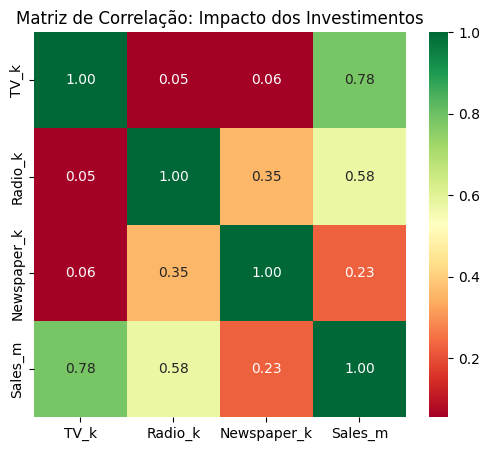

In [80]:

plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriz de Correlação: Impacto dos Investimentos')
plt.show()


## Análise Visual de Tendência (Regplot)
A análise visual confirma e aprofunda os números da matriz de correlação:

- TV x Vendas: Observamos uma linha de tendência ascendente bem definida, com os pontos muito próximos à reta. Isso indica que a TV é um canal previsível e o principal motor de volume para o mix de marketing.

- Rádio vs Vendas: Existe uma inclinação positiva clara, mas os pontos estão mais espalhados do que no gráfico de TV. Isso mostra que rádio é eficaz, mas ele sofre maior influência de fatores externos (ruído).

- Jornal vs Vendas: A "nuvem de pontos" é dispersa e a linha de tendência é quase horizontal em comparação aos outros. O sombreamento ao redor da linha (intervalo de confiança) é mais largo, o que prova que investir em Jornal traz uma alta incerteza de retorno.

Conclusão Estratégica: Para otimizar o orçamento, o foco inicial de modelagem deve priorizar TV e Rádio. O canal de Jornal deve ser reavaliado, pois o custo de aquisição parece não se converter em vendas de forma eficiente. Talvez seja interessante buscar por um novo canal ainda não explorado.

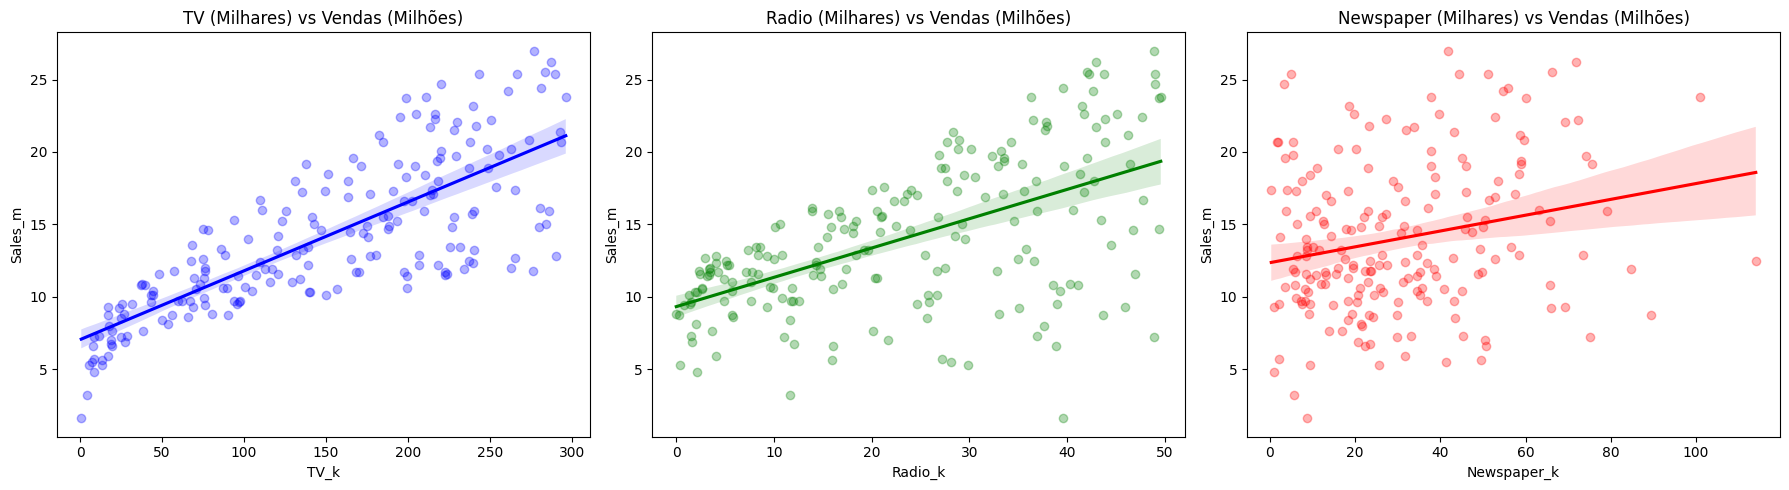

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plotando os 3 canais contra vendas
sns.regplot(data=df, x='TV_k', y='Sales_m', ax=axes[0], color='blue', scatter_kws={'alpha':0.3})
axes[0].set_title('TV (Milhares) vs Vendas (Milhões)')

sns.regplot(data=df, x='Radio_k', y='Sales_m', ax=axes[1], color='green', scatter_kws={'alpha':0.3})
axes[1].set_title('Radio (Milhares) vs Vendas (Milhões)')

sns.regplot(data=df, x='Newspaper_k', y='Sales_m', ax=axes[2], color='red', scatter_kws={'alpha':0.3})
axes[2].set_title('Newspaper (Milhares) vs Vendas (Milhões)')

plt.tight_layout()
plt.show()

# Modelagem: Regressão Linear e Avaliação do Modelo

Nesta seção, ajustaremos um modelo de regressão linear para explicar a variável alvo a partir das variáveis selecionadas, dando continuidade à análise exploratória feita anteriormente.

Em seguida, avaliaremos a qualidade do ajuste utilizando métricas como o coeficiente de determinação (R²), que indica quanto da variação dos dados é explicada pelo modelo, e RMSE que mede o erro médio das previsões na mesma unidade da variável alvo.

In [82]:
# Preparação dos Dados e Divisão de Treino/Teste
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Definindo as variáveis independentes (X) e a dependente (y)
X = df[['TV_k', 'Radio_k', 'Newspaper_k']]
y = df['Sales_m']

# Dividindo os dados: 80% para treino e 20% para testar a performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6292)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 160 amostras
Teste: 40 amostras


In [83]:
# Treinamento do Modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

## Avaliando o Modelo de Regressão

Abaixo podemos conferir a confiabilidade no Modelo treinado. Note que no gráfico Real vs. Previsto, quanto mais próximos os pontos estiverem da linha vermelha tracejada, mais preciso é o seu modelo.


- R²: Diz quanto o modelo explica a variação das vendas (0 a 1).
- RMSE: Diz o erro médio das nossas previsões na unidade de medida ($ milhões).

R² (Coeficiente de Determinação): 0.9338
RMSE (Erro Médio): 1.3229


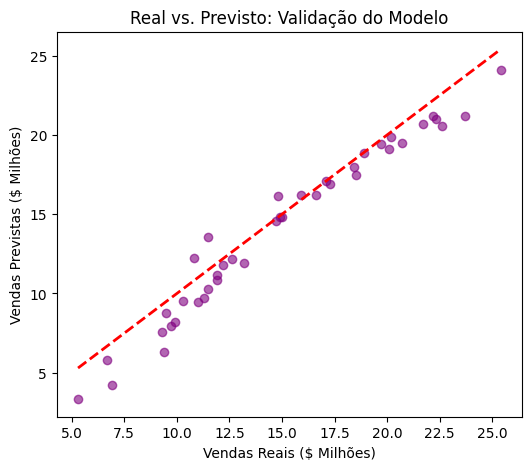

In [84]:
# Avaliação inicial do modelo
print(f"R² (Coeficiente de Determinação): {metrics.r2_score(y_test, y_pred):.4f}")
print(f"RMSE (Erro Médio): {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.4f}")

# Visualizando Predição vs Real
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Vendas Reais ($ Milhões)')
plt.ylabel('Vendas Previstas ($ Milhões)')
plt.title('Real vs. Previsto: Validação do Modelo')
plt.show()

# Extração de Coeficientes e ROI Estimado

O modelo de Regressão Linear cria uma equação. Abaixo iremos  extrair os pesos de cada canal, para entender o retorno de cada $ investido.

In [85]:
# Criando a tabela de coeficientes
coeficiente = pd.DataFrame(modelo.coef_, X.columns, columns=['Impacto Direto'])

print(f"--- ANÁLISE DE IMPACTO (MMM) ---")
print(f"Vendas Base (Orgânico): ${modelo.intercept_:.2f} Milhões")
print("-" * 30)
display(coeficiente)

--- ANÁLISE DE IMPACTO (MMM) ---
Vendas Base (Orgânico): $2.64 Milhões
------------------------------


,Impacto Direto
TV_k,0.046292
Radio_k,0.188970
Newspaper_k,0.000599


Com base no dataframe de coeficientes gerado, observamos que o rádio é o canal com maior retorno por unidade investida:

- O coeficiente de Radio é aproximadamente 0,1890, o que indica que, para cada milhar (\\$1.000) investido, as vendas tendem a aumentar em cerca de $189.000.

- Em TV é cerca de 0,0463 sugerindo que a cada milhar (\$1.000) investido as vendas aumentam em torno \$46.300, embora a TV possa concentrar mais verba e gerar maior volume absoluto de vendas, sua eficiência marginal é inferior à do rádio.

- Já o Jornal mostra impacto praticamente nulo: o coeficiente de Newspaper_k é próximo de 0,0006, indicando que, para cada milhar investido, o incremento médio nas vendas é de apenas \$600, valor tão pequeno que sugere ausência de retorno relevante e reforça a evidência da análise de correlação de que esse canal não contribui de forma significativa para o aumento de vendas, podendo gerar até prejuízo.
​

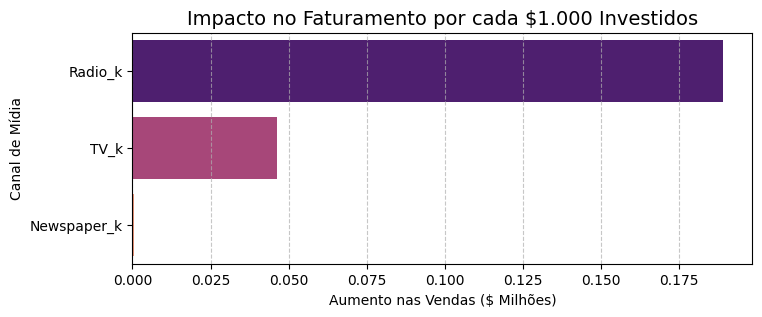

In [86]:
plt.figure(figsize=(8, 3))
coef_sorted = coeficiente['Impacto Direto'].sort_values(ascending=False)
sns.barplot(x=coef_sorted.values, y=coef_sorted.index, palette='magma', hue=coef_sorted.index, legend=False)

plt.title('Impacto no Faturamento por cada $1.000 Investidos', fontsize=14)
plt.xlabel('Aumento nas Vendas ($ Milhões)')
plt.ylabel('Canal de Mídia')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Conclusões e Recomendações de Negócio

Eficiência de Canais: O modelo revelou que o Rádio e a TV possuem os maiores coeficientes. Isso significa que eles são os canais mais eficientes para gerar volume de vendas.

Otimização de Budget: O coeficiente de Newspaper é próximo de zero (ou muito baixo). Estratégicamente, recomendamos reduzir o investimento neste canal e realocá-lo para TV ou Rádio para maximizar o ROI total.

Ponto de Partida: Mesmo se parássemos de investir hoje, o modelo estima uma venda base de aproximadamente $2.64 Milhões (vendas orgânicas), o que representa a força da marca já consolidada.

# Simulação de Cenário
*"What-if?"*

Como ficaria o resultado, se todo o capital alocado em Newspaper/Jornal, fosse alocado entre as outras duas modalidades?

In [101]:
# Definindo os investimentos atuais médios
investimento_atual = X.mean()

# Criando o cenário otimizado:
# Pegamos o valor de Newspaper e dividimos 50/50 entre TV e Radio
cenario_otimizado = investimento_atual.copy()
verba_jornal = cenario_otimizado['Newspaper_k']

cenario_otimizado['TV_k'] += verba_jornal * 0.5
cenario_otimizado['Radio_k'] += verba_jornal * 0.5
cenario_otimizado['Newspaper_k'] = 0

# Predição de Vendas
# Convertendo as Series para DataFrame com os nomes das colunas esperados
venda_atual = modelo.predict(pd.DataFrame([investimento_atual]))[0]
venda_otimizada = modelo.predict(pd.DataFrame([cenario_otimizado]))[0]

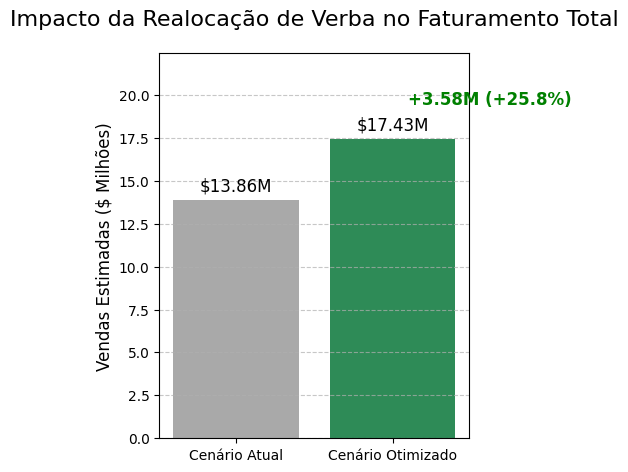


Faturamento Médio Atual: $13.86M
Faturamento com Verba Realocada: $17.43M
Aumento Estimado: $3.58M
Percentual de Crescimento: 25.81%


In [117]:
cenarios = ['Cenário Atual', 'Cenário Otimizado']
faturamentos = [venda_atual, venda_otimizada]

plt.figure(figsize=(4, 5))
bars = plt.bar(cenarios, faturamentos, color=['#A9A9A9', '#2E8B57'])

# Adicionando os valores em cima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f'${yval:.2f}M',
             ha='center', va='bottom', fontsize=12)

plt.title('Impacto da Realocação de Verba no Faturamento Total', fontsize=16, pad=20)
plt.ylabel('Vendas Estimadas ($ Milhões)', fontsize=12)
plt.ylim(0, max(faturamentos) + 5) # Espaço extra para o texto
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Destaque para o aumento
plt.annotate(f'+{venda_otimizada - venda_atual:.2f}M (+25.8%)',
             xy=(1, venda_otimizada), xytext=(1.1, venda_otimizada + 2),

             fontsize=12, color='green', fontweight='bold')

plt.show()

print(f"\nFaturamento Médio Atual: ${venda_atual:.2f}M")
print(f"Faturamento com Verba Realocada: ${venda_otimizada:.2f}M")
print(f"Aumento Estimado: ${venda_otimizada - venda_atual:.2f}M")
print(f"Percentual de Crescimento: {((venda_otimizada/venda_atual)-1)*100:.2f}%")